Using device: cpu  |  PyTorch 2.9.1+cpu
MobileNetV2 params: 3,504,872
ResNet50    params: 25,557,032
Loaded ImageNet labels
Loaded example image dog.jpg from c:\Users\HP\Desktop\HLS\dog.jpg
Loaded example image cat.jpg from c:\Users\HP\Desktop\HLS\cat.jpg
Loaded example image car.jpg from c:\Users\HP\Desktop\HLS\car.jpg
No test_images/ or HLS/ images found — using the example images (if present).
No labels.csv found — file-based ground-truth will be skipped (FakeData still provides labels).

Evaluating model: MobileNetV2
dog.jpg                                  | softmax # 263 ( 89.5%) | paperCU # 263 (ACmax=18.020) | agree=True
cat.jpg                                  | softmax # 281 ( 61.6%) | paperCU # 281 (ACmax=13.918) | agree=True
car.jpg                                  | softmax # 581 ( 56.4%) | paperCU # 581 (ACmax=14.785) | agree=True

--- Aggregated results ---
Images evaluated                 : 3
Avg model forward time           : 94.4443 ms
Avg softmax classifier          

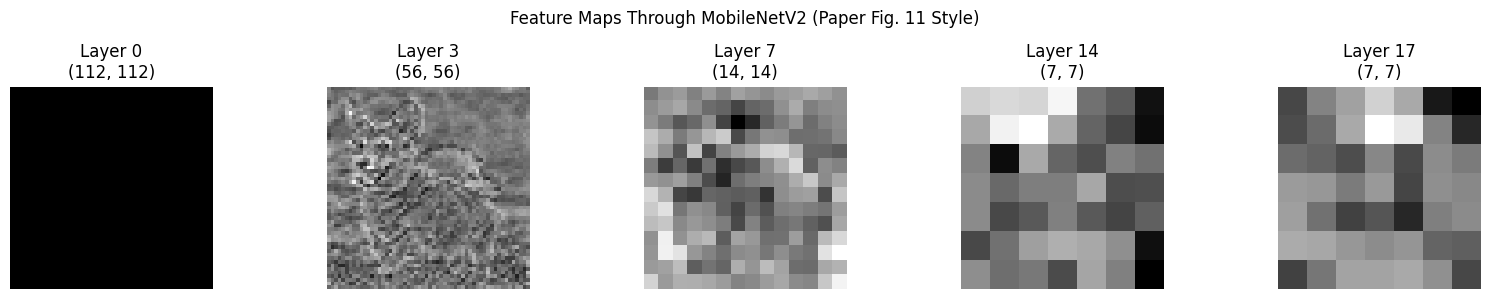

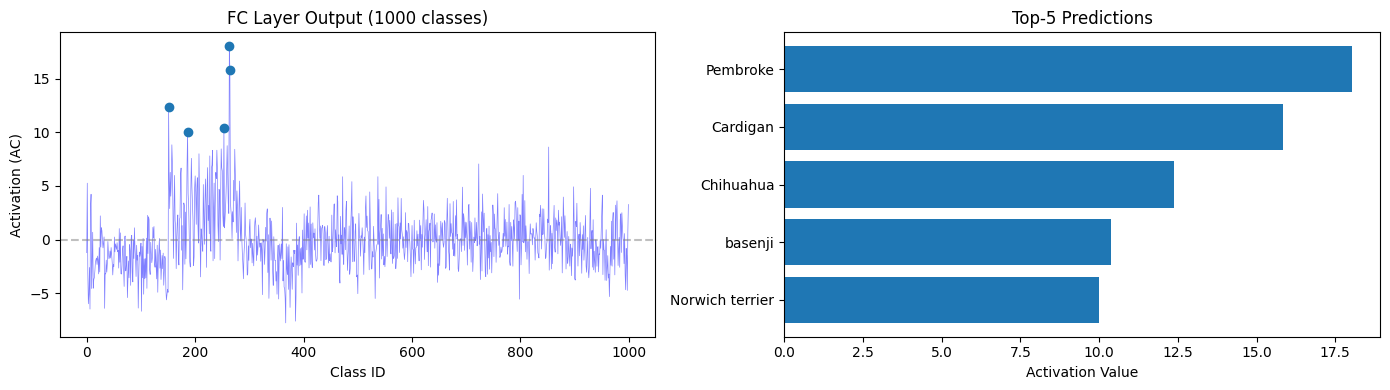


All done. CSVs saved to your working directory.


In [5]:
# Full pipeline: multi-image speed + accuracy eval (updated: top-1/top-5, FakeData fallback)
import time, csv, io
from pathlib import Path
from typing import Dict, List, Tuple
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# Device & models
# ---------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}  |  PyTorch {torch.__version__}")

mobilenet = models.mobilenet_v2(weights='IMAGENET1K_V1').eval().to(device)
resnet = models.resnet50(weights='IMAGENET1K_V1').eval().to(device)

print(f"MobileNetV2 params: {sum(p.numel() for p in mobilenet.parameters()):,}")
print(f"ResNet50    params: {sum(p.numel() for p in resnet.parameters()):,}")

# ---------------------------
# Q8.8 quantizer (paper-style)
# ---------------------------
class FixedPointQuantizer:
    def __init__(self, total_bits=16, frac_bits=8):
        self.scale = 2 ** frac_bits
        self.qmin = -(2 ** (total_bits - 1))
        self.qmax = (2 ** (total_bits - 1)) - 1
    def quantize(self, x: torch.Tensor) -> torch.Tensor:
        xi = torch.round(x * self.scale)
        xi = torch.clamp(xi, self.qmin, self.qmax)
        return xi / float(self.scale)

quantizer = FixedPointQuantizer()

# ---------------------------
# Labels & preprocess
# ---------------------------
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
try:
    import urllib.request
    req = urllib.request.Request(LABELS_URL, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=10) as resp:
        imagenet_classes = resp.read().decode().strip().splitlines()
    print("Loaded ImageNet labels")
except Exception:
    imagenet_classes = [f"class_{i}" for i in range(1000)]
    print("Could not download ImageNet labels — using placeholders")

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
def prepare_input(img): 
    # accepts PIL Image or Tensor already shaped [C,H,W]
    if isinstance(img, torch.Tensor):
        t = img.unsqueeze(0).to(device)
    else:
        t = preprocess(img).unsqueeze(0).to(device)
    return t

# ---------------------------
# Discover local images (search cwd + immediate subfolders)
# ---------------------------
wanted = ['dog.jpg', 'cat.jpg', 'car.jpg']
cwd = Path.cwd()
candidates = [cwd] + [p for p in cwd.iterdir() if p.is_dir()]
found = {}
for folder in candidates:
    for fname in wanted:
        p = folder / fname
        if p.exists():
            found[fname] = p

loaded_images = {}
for fname, p in found.items():
    name = Path(fname).stem
    img = Image.open(p).convert('RGB')
    loaded_images[name] = {'path': str(p), 'pil': img}
    print(f"Loaded example image {fname} from {p}")

# ---------------------------
# Gather the larger test set:
# Priority:
#   1) test_images/ folder (flat)
#   2) 'HLS' folder (your project folder)
#   3) fallback to discovered loaded_images (dog/cat/car)
#   4) FINAL fallback: torchvision.datasets.FakeData (synthetic) with 1000 classes
# ---------------------------
TEST_IMAGES_DIR = cwd / "test_images"
HLS_DIR = cwd / "HLS"
exts = (".jpg", ".jpeg", ".png", ".bmp")

def collect_images_from_folder(folder: Path) -> List[Path]:
    if not folder.exists() or not folder.is_dir():
        return []
    imgs = [p for p in sorted(folder.iterdir()) if p.suffix.lower() in exts and p.is_file()]
    return imgs

test_image_paths = collect_images_from_folder(TEST_IMAGES_DIR)
if test_image_paths:
    print(f"Using {len(test_image_paths)} images from {TEST_IMAGES_DIR}")
else:
    test_image_paths = collect_images_from_folder(HLS_DIR)
    if test_image_paths:
        print(f"Using {len(test_image_paths)} images from {HLS_DIR}")
    else:
        # fallback to the example images found earlier
        print("No test_images/ or HLS/ images found — using the example images (if present).")
        for name, meta in loaded_images.items():
            test_image_paths.append(Path(meta['path']))

use_fake_dataset = False
fake_dataset = None
if not test_image_paths:
    # create synthetic dataset of 500 samples with 1000 classes for accurate top-k behavior
    print("No local images found — falling back to torchvision.datasets.FakeData (synthetic) with 500 images).")
    fake_dataset = datasets.FakeData(size=500, image_size=(3,224,224), num_classes=1000, transform=transforms.ToPILImage())
    use_fake_dataset = True

# ---------------------------
# Optional labels CSV for true accuracy (file-based)
# ---------------------------
LABELS_CSV = cwd / "labels.csv"
def load_labels_map(csv_path: Path) -> Dict[str,int]:
    if not csv_path.exists():
        return {}
    lab = {}
    with open(csv_path, 'r', newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row: continue
            try:
                fname = row[0].strip()
                lbl = int(row[1])
                lab[fname] = lbl
            except Exception:
                continue
    return lab

labels_map = load_labels_map(LABELS_CSV)
if labels_map:
    print(f"Loaded {len(labels_map)} labels from {LABELS_CSV}")
else:
    print("No labels.csv found — file-based ground-truth will be skipped (FakeData still provides labels).")

# ---------------------------
# Classifier helpers (timed) + top-k helpers
# ---------------------------
@torch.no_grad()
def softmax_classify_and_time(logits: torch.Tensor, topk: int = 5):
    t0 = time.perf_counter()
    probs = torch.softmax(logits, dim=-1)
    topk_vals, topk_idx = torch.topk(probs, k=topk, dim=-1)
    idx = int(topk_idx[0,0].cpu().item())
    conf = float(topk_vals[0,0].cpu().item())
    t1 = time.perf_counter()
    # return topk lists (cpu ints/floats)
    topk_idx_list = [int(x) for x in topk_idx[0].cpu().tolist()]
    topk_val_list = [float(x) for x in topk_vals[0].cpu().tolist()]
    return idx, conf, (t1 - t0), topk_idx_list, topk_val_list

@torch.no_grad()
def papercu_classify_and_time(q_logits: torch.Tensor, topk: int = 5):
    t0 = time.perf_counter()
    # paperCU: argmax on quantized activations; to produce top-k we use topk on q_logits
    topk_vals, topk_idx = torch.topk(q_logits, k=topk, dim=-1)
    idx = int(topk_idx[0,0].cpu().item())
    acmax = float(topk_vals[0,0].cpu().item())
    t1 = time.perf_counter()
    topk_idx_list = [int(x) for x in topk_idx[0].cpu().tolist()]
    topk_val_list = [float(x) for x in topk_vals[0].cpu().tolist()]
    return idx, acmax, (t1 - t0), topk_idx_list, topk_val_list

# ---------------------------
# Evaluate models on test images (compute top-1 & top-5 for both classifiers)
# ---------------------------
models_to_eval = [("MobileNetV2", mobilenet), ("ResNet50", resnet)]
detailed_rows = []
summary = {}

TOPK = 5

for model_name, model in models_to_eval:
    print("\n" + "="*72)
    print(f"Evaluating model: {model_name}")
    print("="*72)

    # warm-up
    try:
        if use_fake_dataset:
            sample_img, _ = fake_dataset[0]
        else:
            sample_img_path = test_image_paths[0]
            if sample_img_path.name in loaded_images:
                sample_img = loaded_images[sample_img_path.name]['pil']
            else:
                sample_img = Image.open(sample_img_path).convert('RGB')
        sample_inp = prepare_input(sample_img)
        with torch.no_grad():
            for _ in range(5):
                _ = model(sample_inp)
    except Exception:
        pass

    # counters
    n_images = len(fake_dataset) if use_fake_dataset else len(test_image_paths)
    total_model_forward = 0.0
    total_softmax = 0.0
    total_papercu = 0.0

    agreement = 0

    soft_top1 = 0
    soft_top5 = 0
    paper_top1 = 0
    paper_top5 = 0

    labeled_count_for_acc = 0
    labeled_soft_top1 = 0
    labeled_soft_top5 = 0
    labeled_paper_top1 = 0
    labeled_paper_top5 = 0

    for idx_sample in range(n_images):
        # load image + optional ground-truth label
        if use_fake_dataset:
            pil_img, gt_label = fake_dataset[idx_sample]  # pil_img is PIL (transform used)
            display_name = f"fake_{idx_sample:04d}.png"
            gt_available = True
        else:
            img_path = test_image_paths[idx_sample]
            if img_path.name in loaded_images:
                pil_img = loaded_images[img_path.name]['pil']
                display_name = Path(loaded_images[img_path.name]['path']).name
            else:
                pil_img = Image.open(img_path).convert('RGB')
                display_name = img_path.name
            if display_name in labels_map:
                gt_label = labels_map[display_name]
                gt_available = True
            else:
                gt_label = -1
                gt_available = False

        inp = prepare_input(pil_img)

        # model forward timing (FP32)
        t0 = time.perf_counter()
        with torch.no_grad():
            logits = model(inp)  # [1,1000]
        t1 = time.perf_counter()
        model_forward_time = t1 - t0
        total_model_forward += model_forward_time

        # softmax classifier (topk)
        s_idx, s_conf, s_time, s_topk_idx, s_topk_vals = softmax_classify_and_time(logits, topk=TOPK)
        total_softmax += s_time

        # paper CU classifier on quantized logits (topk on q_logits)
        q_logits = quantizer.quantize(logits)
        p_idx, p_acmax, p_time, p_topk_idx, p_topk_vals = papercu_classify_and_time(q_logits, topk=TOPK)
        total_papercu += p_time

        # agreement
        if s_idx == p_idx:
            agreement += 1

        # top-k correctness counting
        # softmax
        if gt_available:
            if s_idx == gt_label:
                soft_top1 += 1
            if gt_label in s_topk_idx:
                soft_top5 += 1
        # paper
        if gt_available:
            if p_idx == gt_label:
                paper_top1 += 1
            if gt_label in p_topk_idx:
                paper_top5 += 1

        # labeled-specific counters (when labels.csv provided in file-based mode)
        if not use_fake_dataset and labels_map:
            labeled_count_for_acc += 1
            if s_idx == gt_label:
                labeled_soft_top1 += 1
            if gt_label in s_topk_idx:
                labeled_soft_top5 += 1
            if p_idx == gt_label:
                labeled_paper_top1 += 1
            if gt_label in p_topk_idx:
                labeled_paper_top5 += 1

        # append detailed row (stringify topk lists for CSV)
        detailed_rows.append({
            "model": model_name,
            "image": display_name,
            "model_forward_time_s": model_forward_time,
            "softmax_time_s": s_time,
            "papercu_time_s": p_time,
            "softmax_pred_top1": s_idx,
            "softmax_conf_top1": s_conf,
            "softmax_top5_ids": "|".join(str(x) for x in s_topk_idx),
            "softmax_top5_vals": "|".join(f"{x:.6f}" for x in s_topk_vals),
            "papercu_pred_top1": p_idx,
            "papercu_acmax_top1": p_acmax,
            "papercu_top5_ids": "|".join(str(x) for x in p_topk_idx),
            "papercu_top5_vals": "|".join(f"{x:.6f}" for x in p_topk_vals),
            "agree": int(s_idx == p_idx),
            "label_available": int(gt_available),
            "label": int(gt_label) if gt_available else -1
        })

        # small print
        print(f"{display_name:40s} | softmax #{s_idx:4d} ({s_conf*100:5.1f}%) | paperCU #{p_idx:4d} (ACmax={p_acmax:.3f}) | agree={s_idx==p_idx}")

    # aggregated metrics
    n = n_images
    avg_forward_ms = (total_model_forward / n) * 1000.0
    avg_softmax_us = (total_softmax / n) * 1e6
    avg_papercu_us = (total_papercu / n) * 1e6
    speedup = (avg_softmax_us / avg_papercu_us) if avg_papercu_us > 0 else float('inf')
    agreement_pct = agreement / n * 100.0

    # overall accuracies (use what is appropriate)
    # If using FakeData, every sample has a ground-truth label (from FakeData) -> use that for overall top1/top5
    overall_soft_top1_pct = (soft_top1 / n * 100.0) if n > 0 and (use_fake_dataset or labels_map) else None
    overall_soft_top5_pct = (soft_top5 / n * 100.0) if n > 0 and (use_fake_dataset or labels_map) else None
    overall_paper_top1_pct = (paper_top1 / n * 100.0) if n > 0 and (use_fake_dataset or labels_map) else None
    overall_paper_top5_pct = (paper_top5 / n * 100.0) if n > 0 and (use_fake_dataset or labels_map) else None

    # labeled-only accuracies (when the user provided labels.csv against filenames)
    labeled_soft_top1_pct = (labeled_soft_top1 / labeled_count_for_acc * 100.0) if labeled_count_for_acc > 0 else None
    labeled_soft_top5_pct = (labeled_soft_top5 / labeled_count_for_acc * 100.0) if labeled_count_for_acc > 0 else None
    labeled_paper_top1_pct = (labeled_paper_top1 / labeled_count_for_acc * 100.0) if labeled_count_for_acc > 0 else None
    labeled_paper_top5_pct = (labeled_paper_top5 / labeled_count_for_acc * 100.0) if labeled_count_for_acc > 0 else None

    print("\n--- Aggregated results ---")
    print(f"Images evaluated                 : {n}")
    print(f"Avg model forward time           : {avg_forward_ms:.4f} ms")
    print(f"Avg softmax classifier           : {avg_softmax_us:.2f} µs")
    print(f"Avg paperCU classifier           : {avg_papercu_us:.2f} µs")
    print(f"Classifier speedup (softmax/paperCU): {speedup:.2f}x")
    print(f"Agreement (softmax==paperCU)     : {agreement}/{n} ({agreement_pct:.2f}%)")
    if overall_soft_top1_pct is not None:
        print(f"Softmax overall top-1 accuracy   : {soft_top1}/{n} ({overall_soft_top1_pct:.2f}%)")
        print(f"Softmax overall top-5 accuracy   : {soft_top5}/{n} ({overall_soft_top5_pct:.2f}%)")
        print(f"PaperCU overall top-1 accuracy   : {paper_top1}/{n} ({overall_paper_top1_pct:.2f}%)")
        print(f"PaperCU overall top-5 accuracy   : {paper_top5}/{n} ({overall_paper_top5_pct:.2f}%)")
    if labeled_count_for_acc > 0:
        print(f"\nLabel-file (labels.csv) count    : {labeled_count_for_acc}")
        print(f"Softmax labeled top-1 accuracy   : {labeled_soft_top1}/{labeled_count_for_acc} ({labeled_soft_top1_pct:.2f}%)")
        print(f"Softmax labeled top-5 accuracy   : {labeled_soft_top5}/{labeled_count_for_acc} ({labeled_soft_top5_pct:.2f}%)")
        print(f"PaperCU labeled top-1 accuracy   : {labeled_paper_top1}/{labeled_count_for_acc} ({labeled_paper_top1_pct:.2f}%)")
        print(f"PaperCU labeled top-5 accuracy   : {labeled_paper_top5}/{labeled_count_for_acc} ({labeled_paper_top5_pct:.2f}%)")

    summary[model_name] = {
        "n_images": n,
        "avg_model_forward_ms": avg_forward_ms,
        "avg_softmax_us": avg_softmax_us,
        "avg_papercu_us": avg_papercu_us,
        "speedup": speedup,
        "agreement": agreement_pct,
        "soft_top1_pct": None if overall_soft_top1_pct is None else float(f"{overall_soft_top1_pct:.6f}"),
        "soft_top5_pct": None if overall_soft_top5_pct is None else float(f"{overall_soft_top5_pct:.6f}"),
        "paper_top1_pct": None if overall_paper_top1_pct is None else float(f"{overall_paper_top1_pct:.6f}"),
        "paper_top5_pct": None if overall_paper_top5_pct is None else float(f"{overall_paper_top5_pct:.6f}"),
        "labeled_count_for_acc": labeled_count_for_acc,
        "labeled_soft_top1_pct": labeled_soft_top1_pct,
        "labeled_soft_top5_pct": labeled_soft_top5_pct,
        "labeled_paper_top1_pct": labeled_paper_top1_pct,
        "labeled_paper_top5_pct": labeled_paper_top5_pct
    }

# Save CSVs
pred_csv = cwd / "predictions.csv"
if detailed_rows:
    with open(pred_csv, 'w', newline='', encoding='utf-8') as f:
        fieldnames = list(detailed_rows[0].keys())
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(detailed_rows)
    print("\nSaved per-image predictions+timings to:", pred_csv)
else:
    print("No detailed rows to save.")

summary_csv = cwd / "speed_accuracy_results.csv"
with open(summary_csv, 'w', newline='', encoding='utf-8') as f:
    w = csv.writer(f)
    # write header
    w.writerow(["model", "n_images", "avg_model_forward_ms", "avg_softmax_us", "avg_papercu_us", "speedup", "agreement_pct",
                "soft_top1_pct", "soft_top5_pct", "paper_top1_pct", "paper_top5_pct",
                "labeled_count_for_acc", "labeled_soft_top1_pct", "labeled_soft_top5_pct", "labeled_paper_top1_pct", "labeled_paper_top5_pct"])
    for m, vals in summary.items():
        w.writerow([
            m, vals["n_images"], vals["avg_model_forward_ms"], vals["avg_softmax_us"],
            vals["avg_papercu_us"], vals["speedup"], vals["agreement"],
            "" if vals["soft_top1_pct"] is None else f"{vals['soft_top1_pct']:.6f}",
            "" if vals["soft_top5_pct"] is None else f"{vals['soft_top5_pct']:.6f}",
            "" if vals["paper_top1_pct"] is None else f"{vals['paper_top1_pct']:.6f}",
            "" if vals["paper_top5_pct"] is None else f"{vals['paper_top5_pct']:.6f}",
            vals["labeled_count_for_acc"],
            "" if vals["labeled_soft_top1_pct"] is None else f"{vals['labeled_soft_top1_pct']:.6f}",
            "" if vals["labeled_soft_top5_pct"] is None else f"{vals['labeled_soft_top5_pct']:.6f}",
            "" if vals["labeled_paper_top1_pct"] is None else f"{vals['labeled_paper_top1_pct']:.6f}",
            "" if vals["labeled_paper_top5_pct"] is None else f"{vals['labeled_paper_top5_pct']:.6f}",
        ])
print("Saved aggregated summary to:", summary_csv)

# ---------------------------
# (Optional) Visualizations as before
# ---------------------------
try:
    viz_img = None
    if use_fake_dataset:
        viz_img, _ = fake_dataset[0]
    else:
        viz_img_path = test_image_paths[0]
        if viz_img_path.name in loaded_images:
            viz_img = loaded_images[viz_img_path.name]['pil']
        else:
            viz_img = Image.open(viz_img_path).convert('RGB')

    # Feature maps from MobileNetV2 (same approach)
    def get_activations(model, img, layer_indices):
        activations = []
        x = prepare_input(img)
        for i, layer in enumerate(model.features):
            x = layer(x)
            if i in layer_indices:
                activations.append(x.detach().cpu().numpy()[0])
        return activations

    layer_indices = [0, 3, 7, 14, 17]
    activations = get_activations(mobilenet, viz_img, layer_indices)

    fig, axes = plt.subplots(1, len(activations), figsize=(16, 3))
    for idx, act in enumerate(activations):
        feature_map = act[0]  # first channel
        axes[idx].imshow(feature_map, cmap='gray')
        axes[idx].set_title(f'Layer {layer_indices[idx]}\n{feature_map.shape}')
        axes[idx].axis('off')
    plt.suptitle('Feature Maps Through MobileNetV2 (Paper Fig. 11 Style)')
    plt.tight_layout()
    plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
    plt.show()

    # FC output visualization (first test image)
    with torch.no_grad():
        logits = mobilenet(prepare_input(viz_img))[0].cpu().numpy()
    top5_idx = np.argsort(logits)[-5:][::-1]
    top5_vals = logits[top5_idx]
    top5_labels = [imagenet_classes[i][:20] for i in top5_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(logits, 'b-', alpha=0.5, linewidth=0.5)
    ax1.scatter(top5_idx, top5_vals, zorder=5)
    ax1.set_xlabel('Class ID'); ax1.set_ylabel('Activation (AC)')
    ax1.set_title('FC Layer Output (1000 classes)'); ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

    ax2.barh(range(5), top5_vals[::-1])
    ax2.set_yticks(range(5)); ax2.set_yticklabels(top5_labels[::-1])
    ax2.set_xlabel('Activation Value'); ax2.set_title('Top-5 Predictions')

    plt.tight_layout()
    plt.savefig('fc_output.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print("Visualization stage skipped due to error:", e)

print("\nAll done. CSVs saved to your working directory.")
